In [1]:
# importing essential libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset and previewing it
lead_score = pd.read_csv("Lead Scoring.csv")
lead_score.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [3]:
# Check the size of the dataset
lead_score.shape

(9240, 37)

In [4]:
# View Dataset structure information
lead_score.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

In [5]:
lead_score.isnull().sum()
# Counts how many null/NaN values exist per column

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [6]:
lead_score.duplicated().sum()

np.int64(0)

In [7]:
# statistical summary of numeric columns
lead_score.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [8]:
# All the columns in the dataset
lead_score.columns

Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='str')

## Exploratory Data Analysis (EDA)

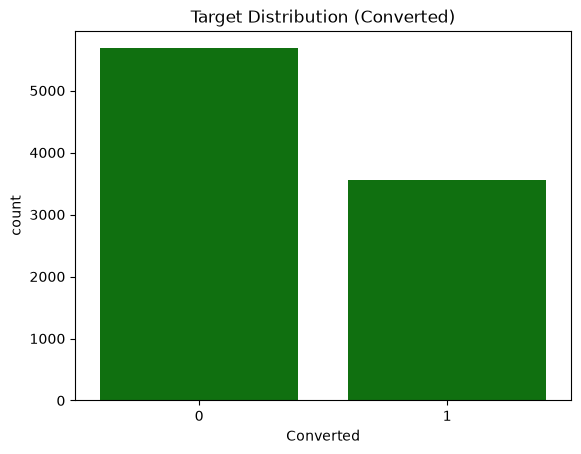

Converted
0    0.61461
1    0.38539
Name: proportion, dtype: float64

In [9]:
# Visualize the target variable distribution
# check the class imbalance before modeling
sns.countplot(x='Converted',color="green", data=lead_score)
# Plots count of each class in 'Converted' column
# x=converted means count 0 is (Not Converted) and 1 is (converted)
plt.title('Target Distribution (Converted)')
plt.show()

lead_score['Converted'].value_counts(normalize=True)
# 0 ->   0.61461(61.46% not converted)
# 1 ->  0.38539 (38.54% converted)

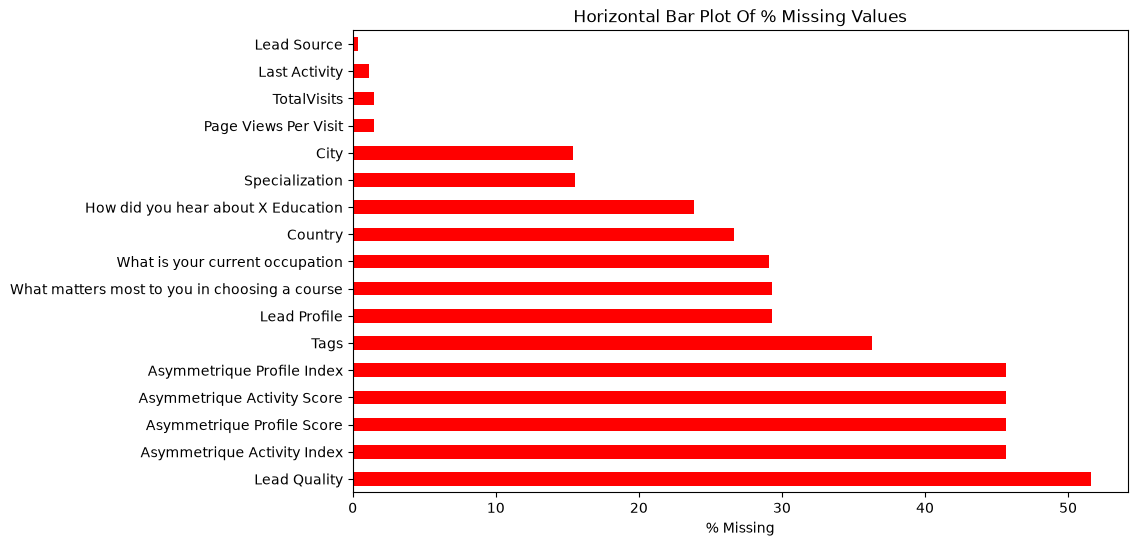

In [10]:
# Check which column has missing values and how much
missing = lead_score.isnull().sum().sort_values(ascending=False)
missing[missing > 0] #Filters to show only columns that has missing values

#Visualize the percentage of missing values
(missing[missing > 0] / len(lead_score) * 100).plot(kind='barh', color="red", figsize=(10, 6))
plt.title("Horizontal Bar Plot Of % Missing Values")
plt.xlabel('% Missing')
plt.show() #Display chart

In [11]:
# Show columns where one value dominates >95%
for col in lead_score.select_dtypes(include=['object', 'string']).columns:
    top_freq = lead_score[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:

        # Print column name, its percentage (:.2% formart as 95.00%), and what that dominant value is
        # No means this column is useless, almost everyone says No
        print(f"{col}: {top_freq:.2%} is '{lead_score[col].value_counts().index[0]}'")

Do Not Call: 99.98% is 'No'
Country: 95.77% is 'India'
What matters most to you in choosing a course: 99.95% is 'Better Career Prospects'
Search: 99.85% is 'No'
Magazine: 100.00% is 'No'
Newspaper Article: 99.98% is 'No'
X Education Forums: 99.99% is 'No'
Newspaper: 99.99% is 'No'
Digital Advertisement: 99.96% is 'No'
Through Recommendations: 99.92% is 'No'
Receive More Updates About Our Courses: 100.00% is 'No'
Update me on Supply Chain Content: 100.00% is 'No'
Get updates on DM Content: 100.00% is 'No'
I agree to pay the amount through cheque: 100.00% is 'No'


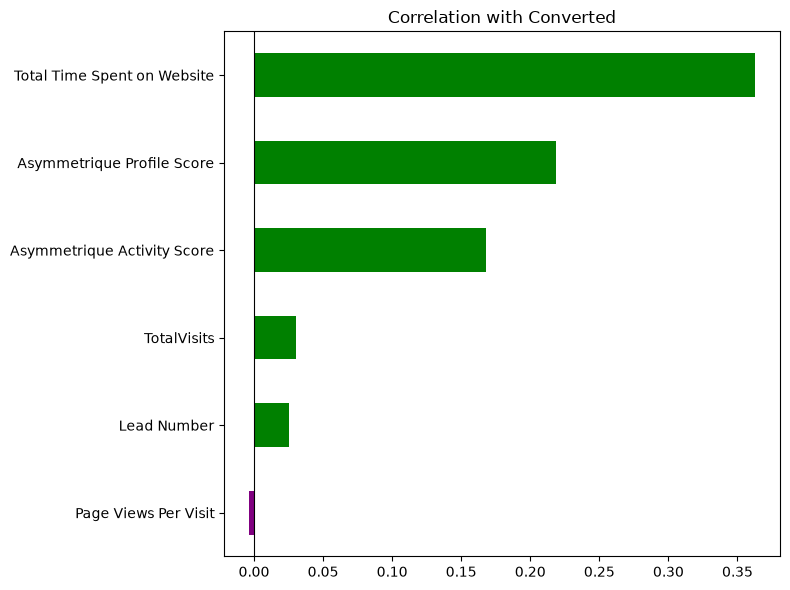

In [12]:
corr = lead_score.corr(numeric_only=True)['Converted'].drop('Converted').sort_values()
#corr = lead_score.corr(numeric_only=True) -> Calculates correlation matrix for only numeric columns
# ['Converted'] -> select only correlation with target
# drop('Converted') ->removes self correlation(converted vs converted)
#sort_values() -> sort from negative to most positive correlation

# plot horizontal bar chat
corr.plot(kind='barh', figsize=(8, 6), color=['purple' if v < 0 else 'green' for v in corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation with Converted')
plt.tight_layout()
plt.show()

In [13]:
# Percentage% leads from each city
lead_score["City"].value_counts(normalize=True)*100

City
Mumbai                         41.202046
Select                         28.759591
Thane & Outskirts               9.616368
Other Cities                    8.772379
Other Cities of Maharashtra     5.843990
Other Metro Cities              4.859335
Tier II Cities                  0.946292
Name: proportion, dtype: float64

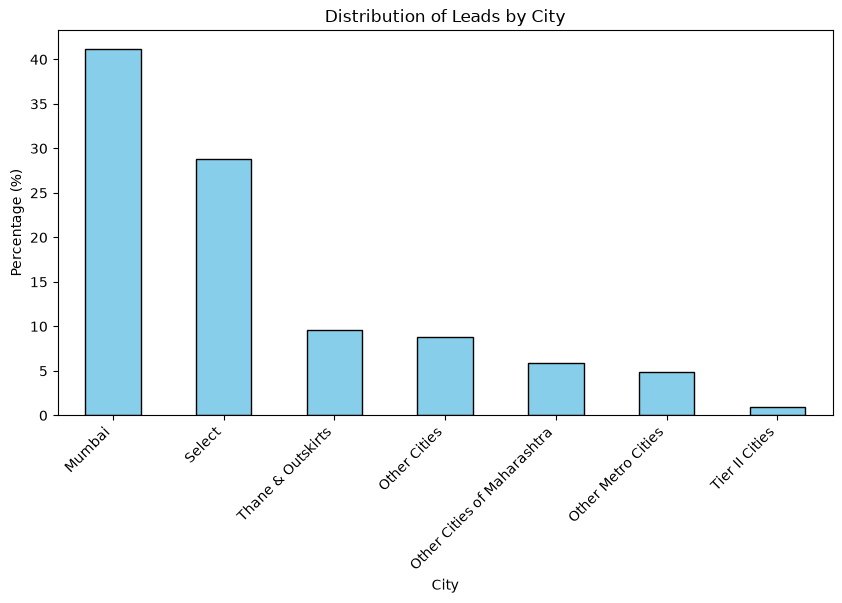

In [14]:
# Percentage% of leads from each city
city_perc = lead_score["City"].value_counts(normalize=True)*100

#Plot bar
plt.figure(figsize=(10,5))
city_perc.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of Leads by City')
plt.ylabel('Percentage (%)')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')
plt.show()

In [15]:
# % of first 20 missing value per column,sorted high to low
(lead_score.isnull().mean() * 100).sort_values(ascending=False).head(20)

Lead Quality                                     51.590909
Asymmetrique Activity Index                      45.649351
Asymmetrique Profile Score                       45.649351
Asymmetrique Activity Score                      45.649351
Asymmetrique Profile Index                       45.649351
Tags                                             36.287879
Lead Profile                                     29.318182
What matters most to you in choosing a course    29.318182
What is your current occupation                  29.112554
Country                                          26.634199
How did you hear about X Education               23.885281
Specialization                                   15.562771
City                                             15.367965
Page Views Per Visit                              1.482684
TotalVisits                                       1.482684
Last Activity                                     1.114719
Lead Source                                       0.3896

## Data Preprocessing

In [16]:
# FEATURE ENGINEERING — Create flags BEFORE dropping columns

# Flag 1: Asymmetrique data availability (~45% missing)
# 1 = data exists, 0 = missing
lead_score['asym_info_available'] = lead_score['Asymmetrique Activity Score'].notnull().astype(int)

# COLUMNS TO DROP — grouped by reason

drop_cols = [
    # ── 1. Identifiers — unique IDs, cause overfitting ────
    'Prospect ID', 'Lead Number',

    # ── 2. Leakage — assigned AFTER the outcome is known ───
    'Tags', 'Lead Quality', 'Last Notable Activity', 'Lead Profile',

    # ── 3. Zero variance — ~99% same value, no signal ────
    'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper',
    'Digital Advertisement', 'Through Recommendations', "A free copy of Mastering The Interview",
    'Receive More Updates About Our Courses', 'Update me on Supply Chain Content',
    'Get updates on DM Content', 'I agree to pay the amount through cheque',
    'Do Not Call', 'Search', 'What matters most to you in choosing a course',

    # ── 4. Redundant / weak — placeholder-dominated ────
    'How did you hear about X Education', 'Country', 'City',

    # ── 5. >40% missing — replaced by asym_info_available flag ──
    'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
    'Asymmetrique Activity Score', 'Asymmetrique Profile Score',
]

In [17]:
# SPLIT INTO FEATURES (X) AND TARGET (y)
X = lead_score.drop(columns=drop_cols + ['Converted'])
y = lead_score['Converted']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Test if the flag actually predicts conversion
print(pd.crosstab(lead_score['asym_info_available'], lead_score['Converted'], normalize='index').round(3))

# 0                    0.608  0.392   ← leads with NO data convert at 39.2%
# 1                    0.620  0.380   ← leads WITH data convert at 38.0%
#
# Difference = only 1.2% → the flag is USELESS
# Verdict: DROP asym_info_available

Converted                0      1
asym_info_available              
0                    0.608  0.392
1                    0.620  0.380


In [20]:
X.isnull().sum()

Lead Origin                           0
Lead Source                          36
Do Not Email                          0
TotalVisits                         137
Total Time Spent on Website           0
Page Views Per Visit                137
Last Activity                       103
Specialization                     1438
What is your current occupation    2690
asym_info_available                   0
dtype: int64

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# SPLIT COLUMNS BY TYPE

# Numeric columns need imputing + scaling
# Categorical columns need imputing + one-hot encoding
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()

print("Numeric:", num_cols)
print("\nCategorical:", cat_cols)

Numeric: ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'asym_info_available']

Categorical: ['Lead Origin', 'Lead Source', 'Do Not Email', 'Last Activity', 'Specialization', 'What is your current occupation']


In [22]:
# BUILD TRANSFORMERS

# Numeric transformer:
#   1. Fill nulls with median (robust to outliers)
#   2. Scale values so all features are on the same range
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer:
#   1. Fill nulls with a literal "unknown" category (don't fabricate)
#   2. One-hot encode → convert categories to 0/1 columns
#      handle_unknown='ignore' → don't crash on unseen categories at test time
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both transformers into one preprocessor
# 'num' branch → applies to numeric columns
# 'cat' branch → applies to categorical columns
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [23]:
# BUILD MODEL PIPELINES
# Logistic Regression — simple baseline model
# max_iter=1000 → give it enough iterations to converge
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000
    ))
])

# Each pipeline = preprocessor + a different model
# Random Forest — shallow trees (max_depth=10) to prevent overfitting
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=6,
        max_depth=10,
        random_state=42
    ))
])


# XGBoost — gradient boosting 
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1
    ))
])

## Model Training

In [24]:
# #Train the full pipeline: impute missing values, scale numeric features,
#encode categoricals,then fit LogisticRegression to learn patterns from X_train to predict y_train
pipe_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Lead Origin','Lead Source','Do Not Email',...,'Specialization', 'What is your current occupation','asym_info_available']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [25]:
#Train the full pipeline: impute missing values, scale numeric features,
#encode categoricals,then fit RandomForest to learn patterns from X_train to predict y_train
pipe_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Lead Origin','Lead Source','Do Not Email',...,'Specialization', 'What is your current occupation','asym_info_available']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [26]:
# #Train the full pipeline: impute missing values, scale numeric features,
#encode categoricals,then fit XGBClassifier to learn patterns from X_train to predict y_train
pipe_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Lead Origin','Lead Source','Do Not Email',...,'Specialization', 'What is your current occupation','asym_info_available']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [27]:
# Evaluate Logistic Regression model - check accuracy on train vs test to spot overfitting
# High train but low test = overfit. Both high and close = good generalization.
print("lr Train score:", pipe_lr.score(X_train, y_train))
print("lr Test score: ", pipe_lr.score(X_test, y_test))

lr Train score: 0.817775974025974
lr Test score:  0.8306277056277056


In [28]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict final label(0=not converted, 1=converted) and probabilities for ROC-AUC
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:, 1]

# Detailed metrics: precision=how many predicted leads were real, recall=how many leads we cought
print(classification_report(y_test, y_pred))
print(f"\nLogisticRegression ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1107
           1       0.81      0.75      0.78       741

    accuracy                           0.83      1848
   macro avg       0.83      0.82      0.82      1848
weighted avg       0.83      0.83      0.83      1848


LogisticRegression ROC-AUC Score: 0.903


In [29]:
# Evaluate RandomForest model - check accuracy on train vs test to spot overfitting
# High train but low test = overfit. Both high and close = good generalization.
print("rf Train score:", pipe_rf.score(X_train, y_train))
print("rf Test score: ", pipe_rf.score(X_test, y_test))

rf Train score: 0.8357683982683982
rf Test score:  0.83495670995671


In [30]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict final label(0=not converted, 1=converted) and probabilities for ROC-AUC
y_pred = pipe_rf.predict(X_test)
y_proba = pipe_rf.predict_proba(X_test)[:, 1]

# Detailed metrics: precision=how many predicted leads were real, recall=how many leads we cought
print(classification_report(y_test, y_pred))
print(f"\nRandomForest ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1107
           1       0.83      0.74      0.78       741

    accuracy                           0.83      1848
   macro avg       0.83      0.82      0.83      1848
weighted avg       0.83      0.83      0.83      1848


RandomForest ROC-AUC Score: 0.908


In [31]:
# Evaluate XGBClassifier model - check accuracy on train vs test to spot overfitting
# High train but low test = overfit. Both high and close = good generalization.
print("xgb Train score:", pipe_xgb.score(X_train, y_train))
print("xgb Test score: ", pipe_xgb.score(X_test, y_test))
#Train 87.7% vs 83.3% = 3.4% gap -> goood generalization, not overfitting too much

xgb Train score: 0.8509199134199135
xgb Test score:  0.8392857142857143


In [32]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict final label(0=not converted, 1=converted) and probabilities for ROC-AUC
y_pred = pipe_xgb.predict(X_test)
y_proba = pipe_xgb.predict_proba(X_test)[:, 1]

# Detailed metrics: precision=how many predicted leads were real, recall=how many leads we cought
print(classification_report(y_test, y_pred))
print(f"\nXGBoostClassifier ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1107
           1       0.81      0.78      0.79       741

    accuracy                           0.84      1848
   macro avg       0.83      0.83      0.83      1848
weighted avg       0.84      0.84      0.84      1848


XGBoostClassifier ROC-AUC Score: 0.910


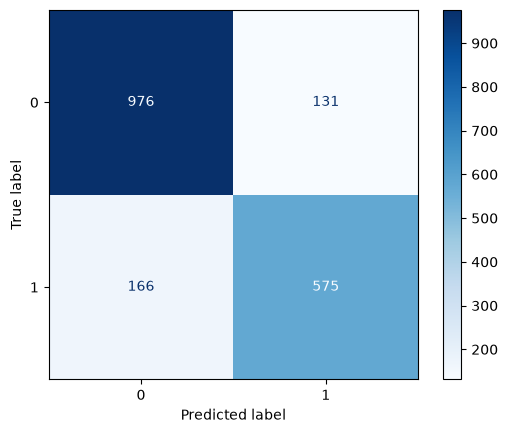

In [33]:
# confusion matrix shows 976 true negatives and 575 true positive
# with 166 false negatives and 131 false posiives, giving 83% accuracy and 0.904 ROC-AUC
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues');

## Hyperparameter Tuning

In [34]:
from sklearn.model_selection import cross_val_score

# cross validation to test pipe_xgb on 5 different train/test split
scores = cross_val_score(
    pipe_xgb,              # your full pipeline (preprocessor + XGBoost)
    X, y,              # full dataset (not split!)
    cv=5,              # 5 folds
    scoring='roc_auc', # metric that matters for imbalanced data
    n_jobs=-1        # use All CPU cores
)

print('AUC Scores:', scores.round(4))
print(f"Mean CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

AUC Scores: [0.8932 0.9237 0.8899 0.9173 0.8576]
Mean CV ROC-AUC: 0.8963 ± 0.0234


In [35]:
# Gridsearch to search for the best XGB settings
from sklearn.model_selection import GridSearchCV, StratifiedKFold

grid = GridSearchCV(
    pipe_xgb,
    {
        'model__n_estimators':  [100, 200], #how many trees to try
        'model__max_depth':     [3, 5, 7], # depth of the tree
        'model__learning_rate': [0.05, 0.1] # how fast it learns
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=42), # 5 fold Stratified keeps class ratio the same
    scoring='roc_auc', #pick model with best AUC
    n_jobs=-1
)

grid.fit(X_train, y_train) # try all combos = 2*3*2 = 12 x 5 folds, keeps class ratio
print(grid.best_params_, round(grid.best_score_, 4))

{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200} 0.9008


## Model Evaluation

In [36]:
best = grid.best_estimator_ # grab the winning model from GridSearchCV
best.fit(X_train, y_train) #return the winning model on train set only

y_pred  = best.predict(X_test) # predict 0/1 - will you buy? uses 0.5 threshold by default
y_proba = best.predict_proba(X_test)[:, 1] #predict chance - e.g 0.82 = 82% chance to buy,

# Lower threshold to catch more buyers (lower threshold = higher recall for buy (1), but more False Positive)
THRESHOLD = 0.35
y_pred = (y_proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred))

print(f"GridSearchCV ROC-AUC: {grid.best_score_:.4f}")
print(f"Train ROC-AUC: {grid.score(X_train, y_train):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}") #predict final score on unseen data

              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1107
           1       0.77      0.86      0.81       741

    accuracy                           0.84      1848
   macro avg       0.83      0.84      0.83      1848
weighted avg       0.84      0.84      0.84      1848

GridSearchCV ROC-AUC: 0.9008
Train ROC-AUC: 0.9191
Test ROC-AUC: 0.9134


[[913 194]
 [107 634]]


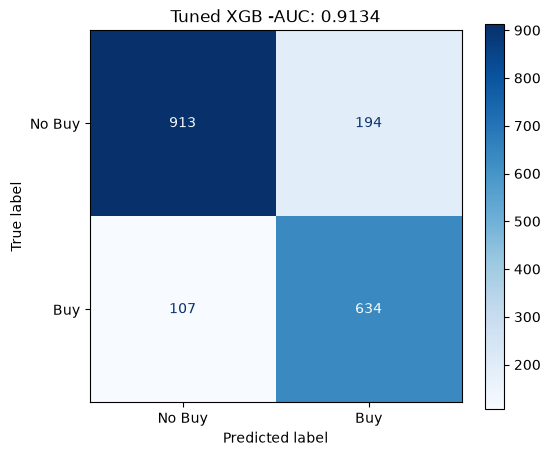

In [37]:
# FINAL TUNED XGB CONFUSION MATRIX
#Model correctly ignores 913 non-buyers and finds 634/712 buyers (86% recall)
# vs Baseline [[984 152][156 556]]: +1 TN, -1 FP, -2 FN +2 TP after GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_best = confusion_matrix(y_test, y_pred)
print(cm_best)

fig, main_ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Buy', 'Buy'])
disp.plot(cmap='Blues', values_format='d', ax=main_ax)

main_ax.set_title(f'Tuned XGB -AUC: {roc_auc_score(y_test, best.predict_proba(X_test)[:, 1]):.4f}');

In [38]:
# Lead Score = probabiliy * 100 (0-100 scale)
y_proba_train = best.predict_proba(X_train)[:,1]
y_proba_test = best.predict_proba(X_test)[:,1]

train_scores = (y_proba_train * 100).astype(int)
test_scores = (y_proba_test * 100).astype(int)

In [39]:
# Add to dataframe
test_results = pd.DataFrame({
    'Lead_Score': test_scores,
    'Actual_Converted': y_test.values,
    'Probability': y_proba_test
})

# proves higher score = higher conversion chance (Decile Analysis)
test_results['Score_Bucket'] = pd.cut(test_results['Lead_Score'],
                                    bins=[0,20,40,60,80,90,100])

In [40]:
# Bin Lead Scores into  buckets for easy reading
conversion_by_bucket = test_results.groupby('Score_Bucket')['Actual_Converted'].mean() *100
print(conversion_by_bucket)

Score_Bucket
(0, 20]       6.874189
(20, 40]     34.939759
(40, 60]     49.193548
(60, 80]     74.489796
(80, 90]     89.240506
(90, 100]    96.256684
Name: Actual_Converted, dtype: float64


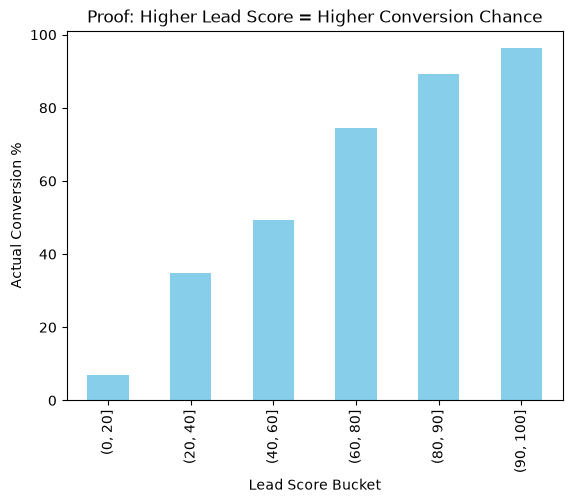

In [41]:
#There is clear positive relationship, as lead score increases, Actual Conversion increases.
conversion_by_bucket.plot(kind='bar',color='skyblue')
plt.title('Proof: Higher Lead Score = Higher Conversion Chance')
plt.ylabel('Actual Conversion %')
plt.xlabel('Lead Score Bucket')
plt.show()

In [42]:
#show first 10 probbility to see what model outputs
# e.g., 0.17 = 17 score, 0.97 = 97 score
print(y_proba_test[:10])

[0.26219556 0.08459835 0.00790291 0.16784412 0.0398123  0.09072984
 0.9815731  0.14539523 0.22152741 0.978576  ]


In [43]:
# Find the best threshold for 80% precision
from sklearn.metrics import precision_score

thresholds = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9] #score cut-offs to test

# Loop through each threshold to see its precision
for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int) # 1 if prob >= threshold else 0
    prec = precision_score(y_test, y_pred_t) # how many hot leads really bought

    # convert threshold to Lead Score
    lead_score = t * 100 # convert 0-1 prob to 0-100 score
    print(f'Lead Score > {lead_score} -> precision: {prec:.2f} ({prec*100:.0f}% will buy)')

Lead Score > 20.0 -> precision: 0.67 (67% will buy)
Lead Score > 30.0 -> precision: 0.74 (74% will buy)
Lead Score > 40.0 -> precision: 0.79 (79% will buy)
Lead Score > 50.0 -> precision: 0.81 (81% will buy)
Lead Score > 60.0 -> precision: 0.84 (84% will buy)
Lead Score > 70.0 -> precision: 0.89 (89% will buy)
Lead Score > 80.0 -> precision: 0.93 (93% will buy)
Lead Score > 90.0 -> precision: 0.96 (96% will buy)


In [44]:
import pandas as pd

# Extract model + feature names from the fitted pipeline
xgb_model = pipe_xgb.named_steps["model"]
preprocessor = pipe_xgb.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

# Build the importance table
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

print(importance.head(20))

                                              feature  importance
6                      cat__Lead Origin_Lead Add Form    0.336280
74       cat__What is your current occupation_unknown    0.080220
73  cat__What is your current occupation_Working P...    0.066934
42                        cat__Last Activity_SMS Sent    0.062221
1                    num__Total Time Spent on Website    0.050899
40         cat__Last Activity_Olark Chat Conversation    0.031881
29                               cat__Do Not Email_No    0.025190
32               cat__Last Activity_Converted to Lead    0.017699
0                                    num__TotalVisits    0.016007
67                        cat__Specialization_unknown    0.015615
36                    cat__Last Activity_Email Opened    0.014872
15                        cat__Lead Source_Olark Chat    0.013410
5            cat__Lead Origin_Landing Page Submission    0.012712
56         cat__Specialization_IT Projects Management    0.010812
10        

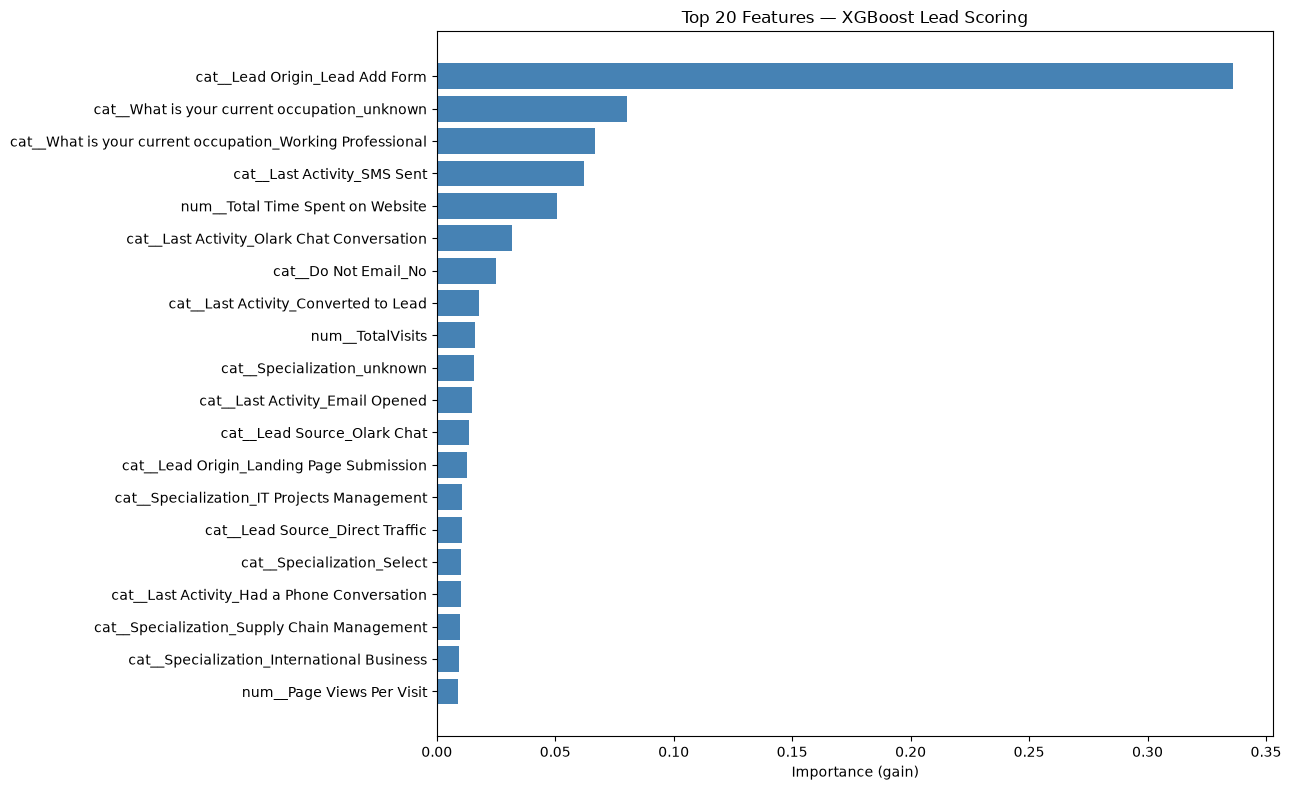

In [45]:
import matplotlib.pyplot as plt

top = importance.head(20).iloc[::-1]   # reverse so biggest is on top

plt.figure(figsize=(13, 8))
plt.barh(top["feature"], top["importance"], color="steelblue")   # "importance" not "importances"
plt.xlabel("Importance (gain)")
plt.title("Top 20 Features — XGBoost Lead Scoring")
plt.tight_layout()
plt.show()

In [46]:
import joblib
import pathlib

In [47]:
desktop = pathlib.Path.home() / "Desktop" / "lead-app"
desktop.mkdir(exist_ok=True)

joblib.dump(best, desktop / 'lead_model.pkl' )

print('DONE! 1 files saved')
print(f"File at: {desktop / 'lead_model.pkl'}")

DONE! 1 files saved
File at: C:\Users\HomePC\Desktop\lead-app\lead_model.pkl
